In [2]:
import yaml
import os
import sys
import json
import numpy as np
import covasim as cv
import matplotlib.pyplot as plt

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


In [3]:
print("PWD =", os.getcwd())

sys.path.append("../intervention_search")

from policies.policy_generator import PolicyGenerator
from simulation.runner import run_evo_simulation
from analysis.detection_delay import summarize_detection
from analysis.intervention_timing import summarize_intervention
from analysis.outbreak_impact import summarize_outbreak
from analysis.mutation_tree import build_mutation_tree
from plotting.plot_mutation_tree import plot_mutation_tree

PWD = /home/jhkim/covasim_project/jhk_covasim4wastewater/weekly_reports


In [4]:
RAW_DIR = "../intervention_search/results/raw"
PROC_DIR = "../intervention_search/results/processed"
FIG_DIR = "../intervention_search/results/figures"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [5]:
with open("../intervention_search/configs/sim_pars.yaml") as f:
    sim_pars = yaml.safe_load(f)

with open("../intervention_search/configs/evo_pars.yaml") as f:
    evo_pars = yaml.safe_load(f)

with open("../intervention_search/configs/policy_sets.yaml") as f:
    policy_sets = yaml.safe_load(f)["policy_sets"]

with open("../intervention_search/configs/intervention_policies.yaml") as f:
    intervention_policies = yaml.safe_load(f)["intervention_policies"]

In [6]:
policy_dict = {
    "baseline": intervention_policies["baseline"],
    "policy_A": intervention_policies["policy_A"],
    "policy_B": intervention_policies["policy_B"],
    "policy_C": intervention_policies["policy_C"],
}

In [7]:
N_ENSEMBLE = 3
results_by_policy = {name: [] for name in policy_dict.keys()}

for pname, policy in policy_dict.items():
    print(f"Running ensemble for {pname}...")
    for seed in range(N_ENSEMBLE):
        sim, obs, interv, variant_metrics, results = run_evo_simulation(
            sim_pars=sim_pars,
            evo_pars=evo_pars["evo_pars"],
            policy=policy,
            rand_seed=seed,
        )

        det = summarize_detection(sim, obs)          # returns: first_detection_day, detection_delay, detection_success_window
        intv = summarize_intervention(obs, interv)   # returns: detection_day, first_intervention_day, intervention_delay, intervention_success
        impact = summarize_outbreak(sim, interv)     # returns: total_infections, peak_infections, ...

        total_diag = int(np.sum(obs.daily_diagnoses))
        total_seq = int(np.sum(obs.daily_sequences))

        result = {
            "policy": pname,
            "seed": seed,
            # detection
            "detection_day": det["first_detection_day"],
            "detection_delay": det["detection_delay"],
            # intervention
            "intervention_day": intv["first_intervention_day"],
            "intervention_delay": intv["intervention_delay"],
            # outbreak impact
            "total_infections": impact["total_infections"],
            "peak_infections": impact["peak_infections"],
            # totals
            "total_diagnoses": total_diag,
            "total_sequences": total_seq,
            "results": results,
        }

        results_by_policy[pname].append(result)

print("All ensembles complete.")


Running ensemble for baseline...
Running ensemble for policy_A...
Running ensemble for policy_B...
Running ensemble for policy_C...
All ensembles complete.


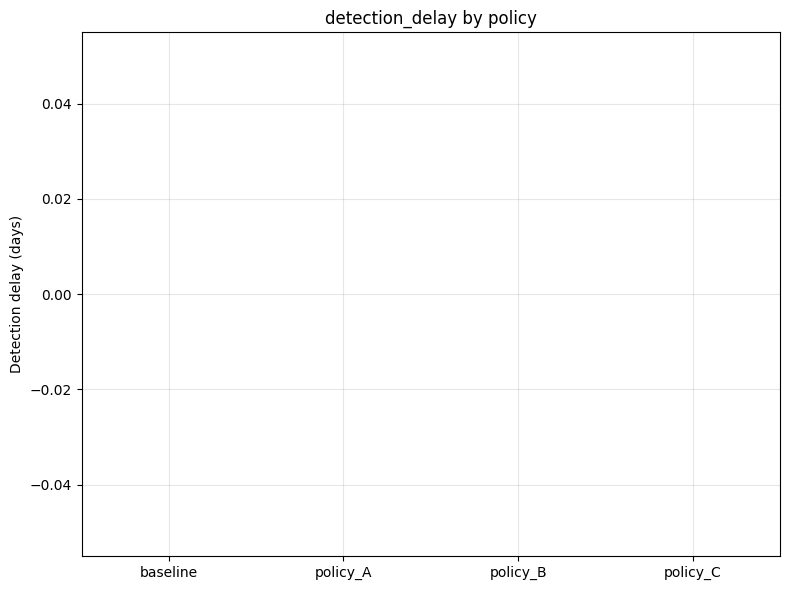

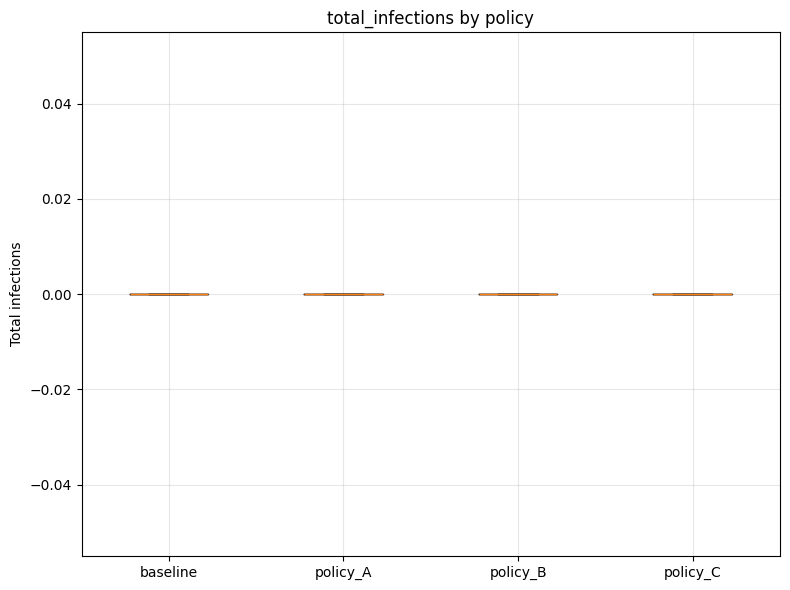

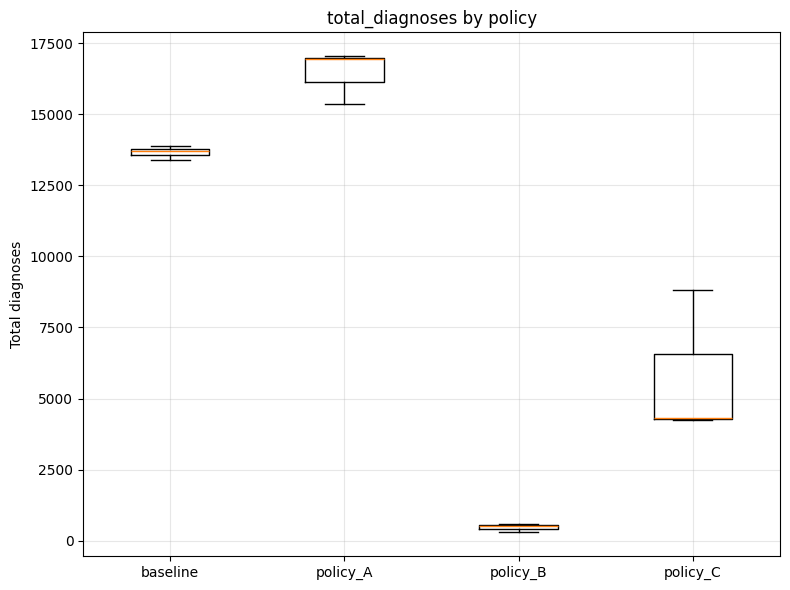

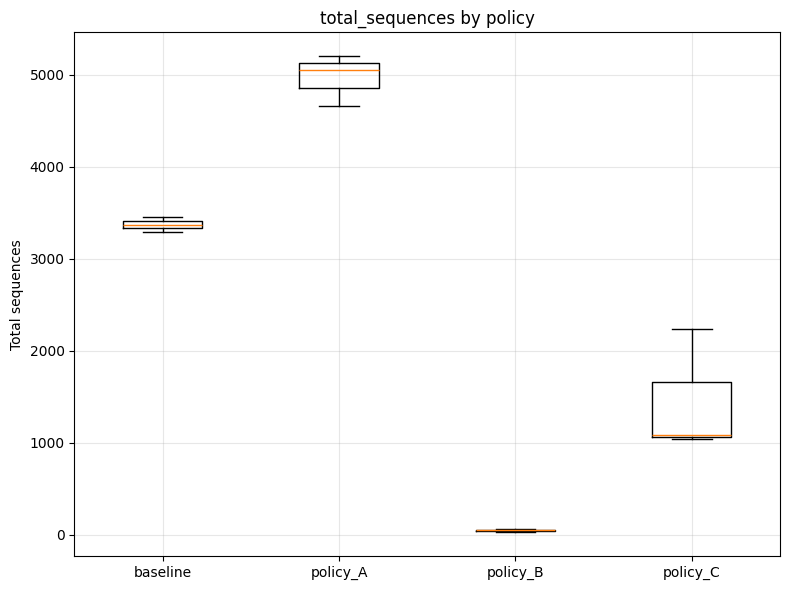

In [8]:
policy_names = ["baseline", "policy_A", "policy_B", "policy_C"]

def grouped_boxplot(metric_key, ylabel, filename):
    data = []
    labels = []
    for pname in policy_names:
        vals = [r[metric_key] for r in results_by_policy[pname] if r[metric_key] is not None]
        data.append(vals)
        labels.append(pname)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.boxplot(data, tick_labels=labels)  # UPDATED
    ax.set_ylabel(ylabel)
    ax.set_title(f"{metric_key} by policy")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, filename), dpi=200)
    plt.show()
    plt.close(fig)

# 1) detection_delay
grouped_boxplot("detection_delay", "Detection delay (days)", "box_detection_delay.png")
# 2) total_infections
grouped_boxplot("total_infections", "Total infections", "box_total_infections.png")
# 3) total_diagnoses
grouped_boxplot("total_diagnoses", "Total diagnoses", "box_total_diagnoses.png")
# 4) total_sequences
grouped_boxplot("total_sequences", "Total sequences", "box_total_sequences.png")

In [9]:
def plot_detailed_policy_run(pname):
    r = sorted(results_by_policy[pname], key=lambda x: x["seed"])[0]
    seed = r["seed"]
    sim, obs, interv, _, results  = run_evo_simulation(
        sim_pars=sim_pars,
        evo_pars=evo_pars["evo_pars"],
        policy=policy_dict[pname],
        rand_seed=seed,
    )

    T = sim.npts
    days = np.arange(T)

    new_inf = sim.results["new_infections"]
    diag = obs.daily_diagnoses
    seqs = obs.daily_sequences

    cum_inf = np.cumsum(new_inf)
    cum_diag = np.cumsum(diag)
    cum_seqs = np.cumsum(seqs)

    # triggers
    gt_triggers = getattr(interv, "gt_triggers", []) 
    diag_triggers = getattr(interv, "diag_triggers", [])

    # intervention timeline
    intervention_days = getattr(interv, "intervention_days", [])
    intervention_end_days = []

    detection_day = r.get("detection_day", None)

    fig, ax = plt.subplots(figsize=(12, 7))

    # daily curves
    ax.plot(days, new_inf, label="New infections", color="tab:blue", alpha=0.6)
    ax.plot(days, diag, label="Diagnoses", color="tab:orange", alpha=0.6)
    ax.plot(days, seqs, label="Sequences", color="tab:green", alpha=0.6)

    # cumulative curves (solid lines)
    ax.plot(days, cum_inf, label="Cum infections", color="tab:blue", linestyle="-")
    ax.plot(days, cum_diag, label="Cum diagnoses", color="tab:orange", linestyle="-")
    ax.plot(days, cum_seqs, label="Cum sequences", color="tab:green", linestyle="-")

    ax2 = ax.twinx()

    # beta_series = [sim.pars["beta"] for _ in range(sim.npts)]

    # ax2.plot(days, beta_series, label="Beta", color="black", linestyle="--", linewidth=1.5)

    # ax2.set_ylabel("Beta", color="black")
    # ax2.tick_params(axis='y', labelcolor='black')

    # GT triggers → dot on cumulative diagnoses
    if len(gt_triggers) > 0:
        ax.scatter(gt_triggers,
                   cum_diag[gt_triggers],
                   color="red", s=5, label="GT triggers")

    # D triggers → dot on cumulative diagnoses
    if len(diag_triggers) > 0:
        ax.scatter(diag_triggers,
                   cum_diag[diag_triggers],
                   color="blue", s=5, label="D triggers")

    # detection day → solid line
    if detection_day is not None:
        ax.axvline(detection_day, color="red", linestyle="-",
                   linewidth=1.5, label=f"Detection day = {detection_day}")

    # intervention start → solid purple
    for d in intervention_days:
        ax.axvline(d, color="purple", linestyle="-", alpha=0.7)

    # intervention end → solid purple
    for d in intervention_end_days:
        ax.axvline(d, color="purple", linestyle="-", alpha=0.7)

    ax.set_xlabel("Day")
    ax.set_ylabel("Count")
    ax.set_title(f"Detailed timeline for policy: {pname}")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"detailed_{pname}.png"), dpi=200)
    plt.show()
    plt.close(fig)


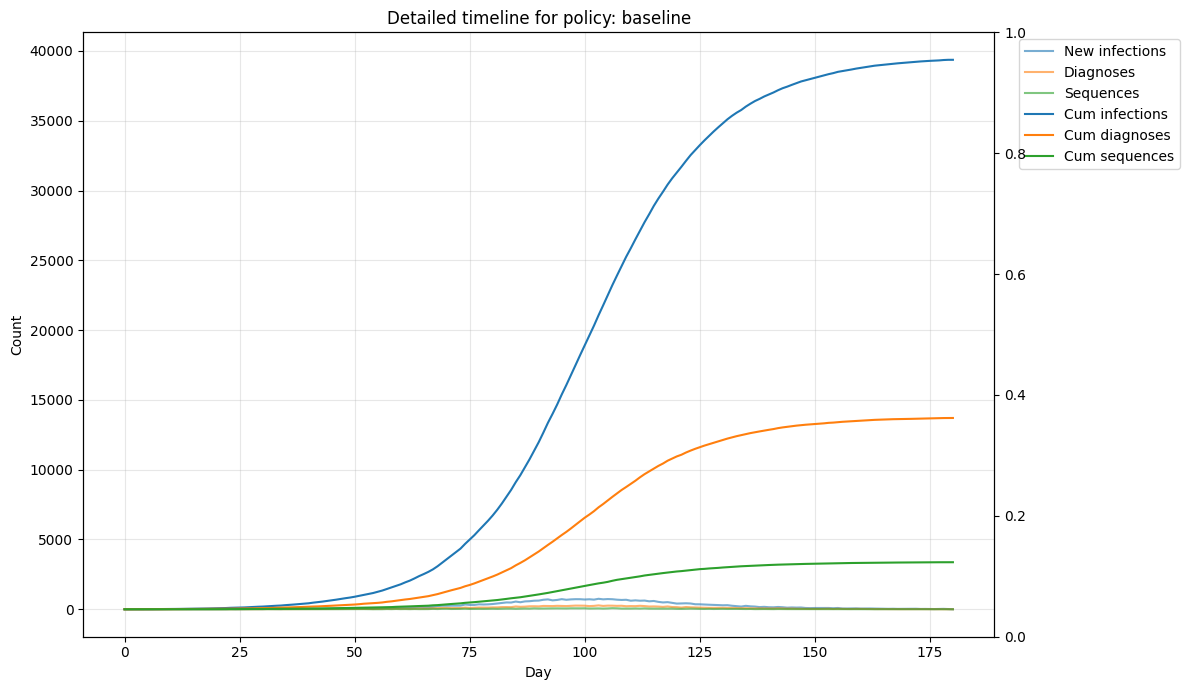

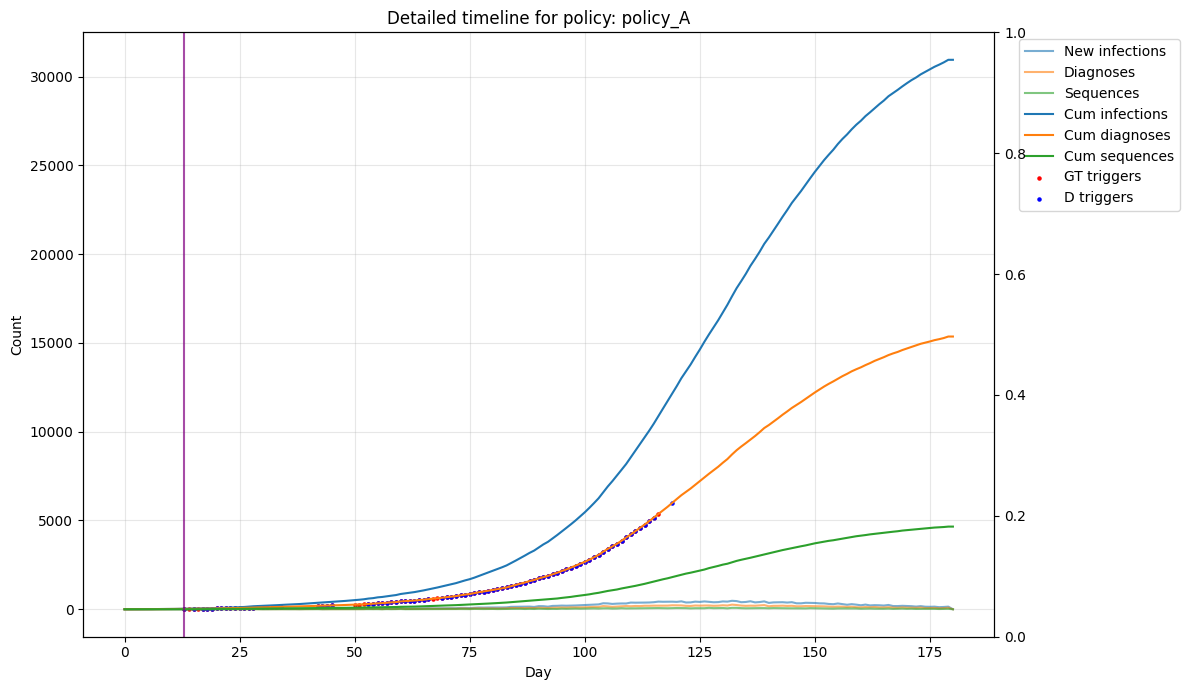

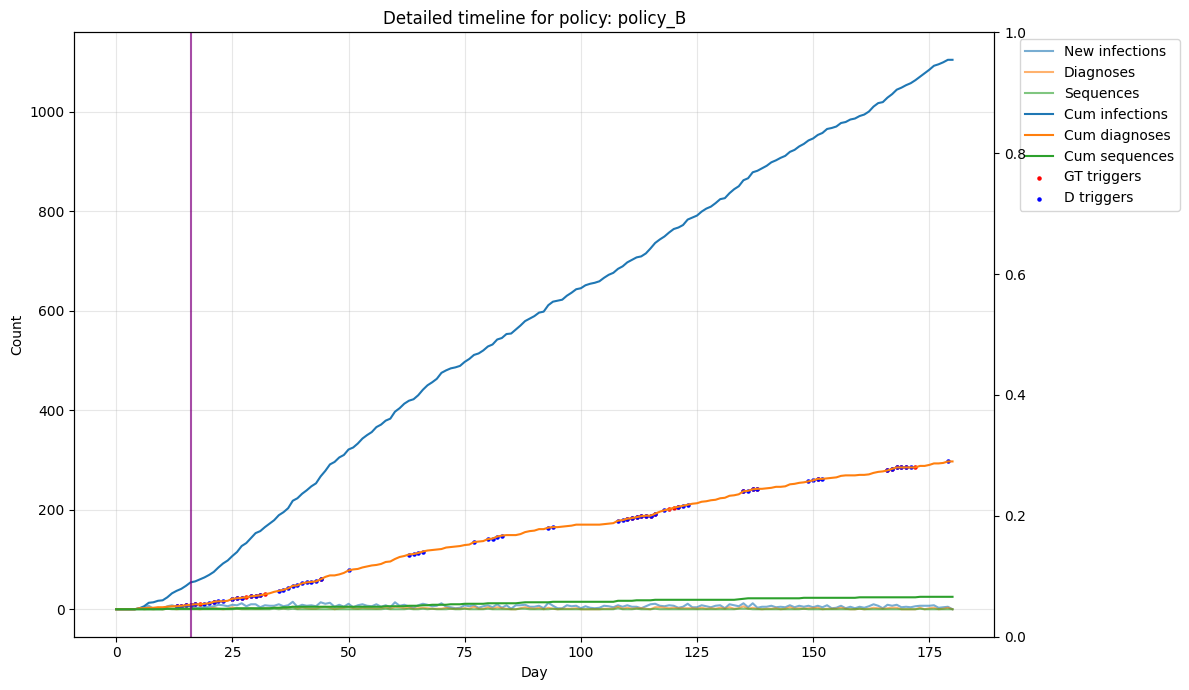

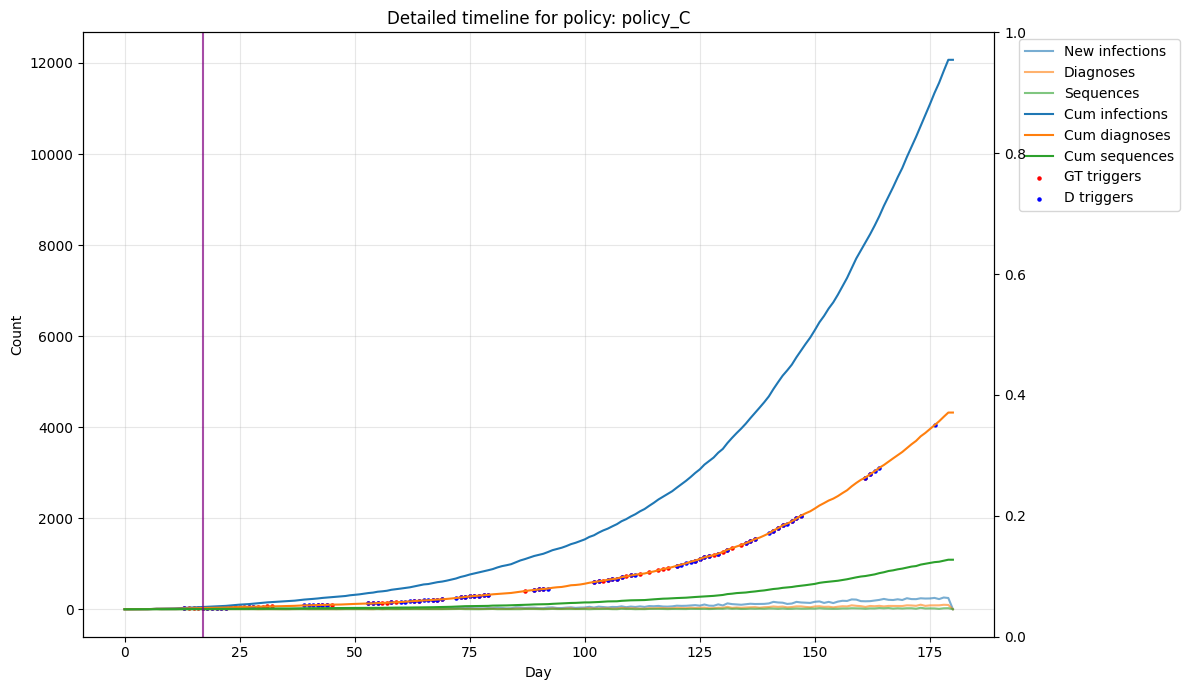

In [10]:
for pname in policy_names:
    plot_detailed_policy_run(pname)

Policy B mutation tree: nodes=1145, edges=1144


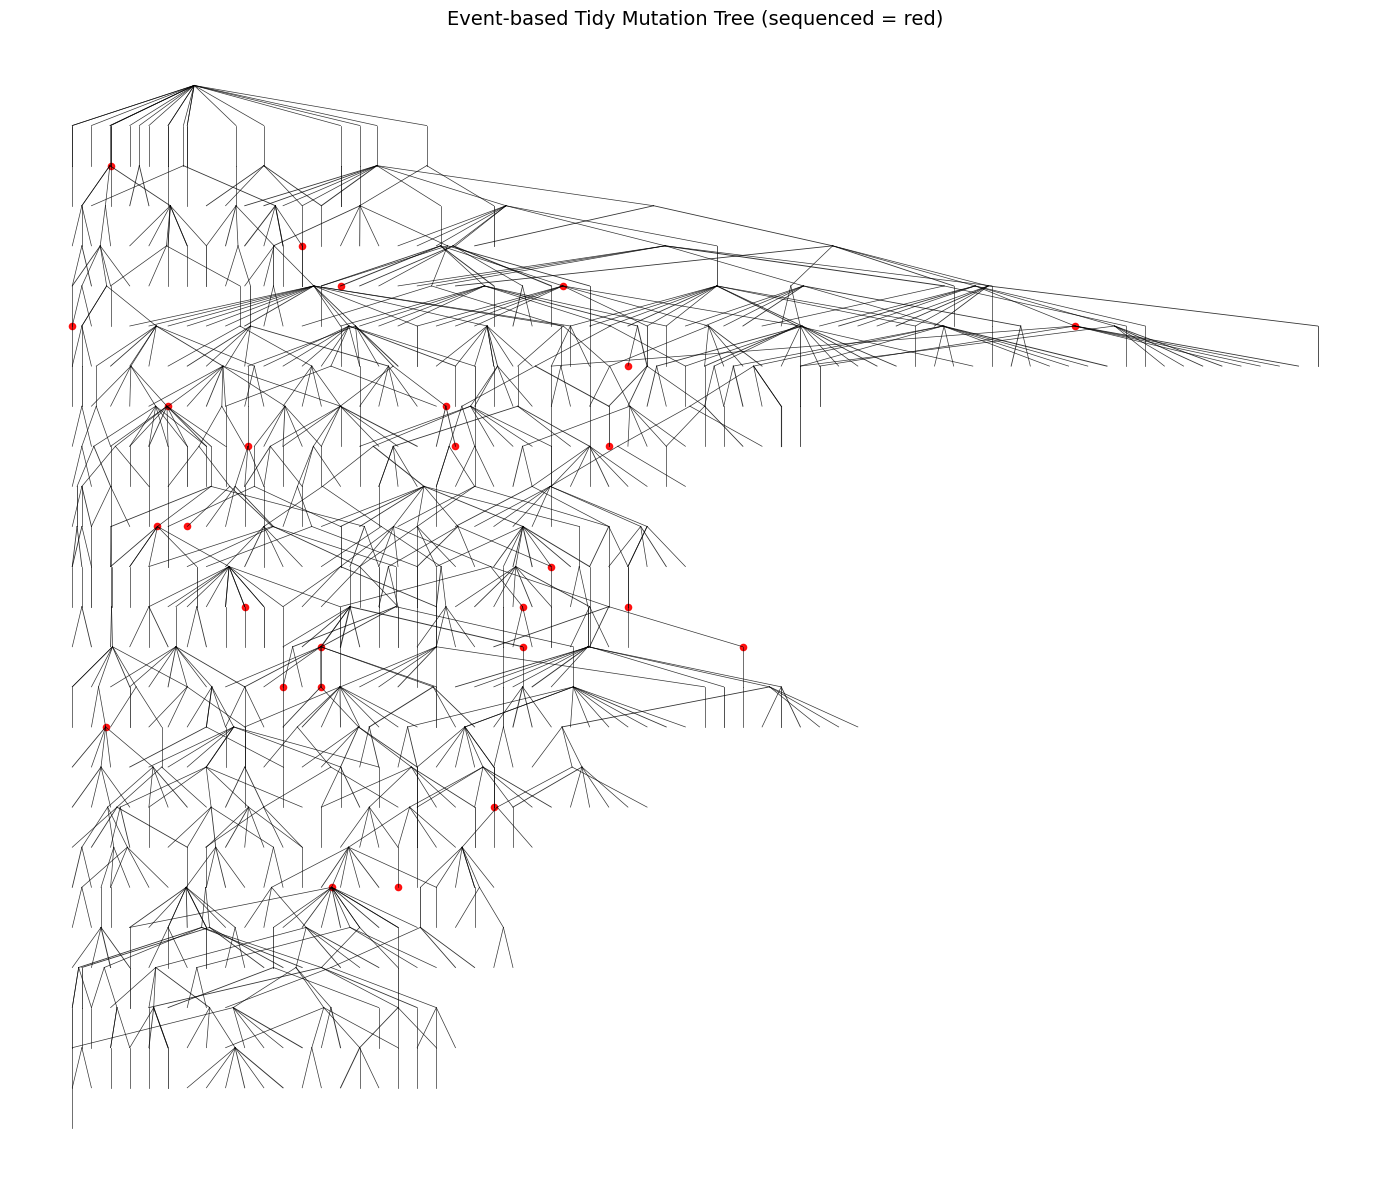

In [11]:
policy_name = "policy_B"
policy_run = sorted(results_by_policy[policy_name], key=lambda x: x["seed"])[0]
seedB = policy_run["seed"]

simB, obsB, intervB, _, results = run_evo_simulation(
    sim_pars=sim_pars,
    evo_pars=evo_pars["evo_pars"],
    policy=policy_dict[policy_name],
    rand_seed=seedB,
)

sequenced_agents = set()
for day_list in obsB.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(simB, sequenced_agents=sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policyB_full.png"),
    detection_day=policy_run["detection_day"],
    sequenced_only=False,
    collapse=False,
)
